In [15]:
# CELL 0: Configuración del entorno
"""
Centraliza:
  - Rutas del proyecto (pathlib — independiente del SO)
  - Paleta visual institucional (inspiración BCRP / The Economist)
  - Parámetros globales del análisis
  - rcParams de Matplotlib para figuras publicación-quality (300 DPI)
"""
 
import warnings
warnings.filterwarnings('ignore')
 
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt

PALETTE = {
    'primary'  : '#1A4C7A',
    'secondary': '#C8A951',
    'accent'   : '#2E7D32',
    'danger'   : '#C62828',
    'warning'  : '#E65100',
    'neutral'  : '#546E7A',
    'bg'       : '#F5F5F0',
    'grid'     : '#D8D8D0',
    'text'     : '#1C1C2E',
}

MICRO_COLORS = ['#1A4C7A', '#C8A951', '#2E7D32', '#8E44AD', '#C0392B']
 
CMAP_RENDIMIENTO = 'YlGn'
CMAP_RIESGO      = 'RdYlGn'
 
# Rutas del proyecto
_BASE = (
    r"G:\2026\Trabajos\Agriapatial-ML descubrimiento de microclimas y predicción "
    r"de rendimientos mediante inteligencia artificial\spatial-agri-production"
)
BASE_DIR   = Path(_BASE)
RUTA_MAPA  = BASE_DIR / "data" / "raw" / "Provincial INEI 2023 geogpsperu SuyoPomalia.shp"
RUTA_CSV   = BASE_DIR / "data" / "produccion_quinua.csv"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
 
# Parámetros de análisis
AÑO_ANALISIS  : int   = 2023
N_MICROCLIMAS : int   = 3
CONTAMINATION : float = 0.15
RANDOM_STATE  : int   = 42
API_DELAY_S   : float = 0.7
API_RETRIES   : int   = 3
 
# Estilo Matplotlib
mpl.rcParams.update({
    'figure.facecolor'   : PALETTE['bg'],
    'axes.facecolor'     : PALETTE['bg'],
    'axes.edgecolor'     : PALETTE['grid'],
    'axes.labelcolor'    : PALETTE['text'],
    'axes.titlesize'     : 15,
    'axes.titleweight'   : 'bold',
    'axes.titlecolor'    : PALETTE['text'],
    'axes.titlepad'      : 14,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'xtick.color'        : PALETTE['neutral'],
    'ytick.color'        : PALETTE['neutral'],
    'text.color'         : PALETTE['text'],
    'font.family'        : 'DejaVu Sans',
    'legend.framealpha'  : 0.92,
    'legend.edgecolor'   : PALETTE['grid'],
    'legend.fontsize'    : 9,
    'figure.dpi'         : 130,
    'savefig.dpi'        : 300,
    'savefig.bbox'       : 'tight',
    'savefig.facecolor'  : PALETTE['bg'],
})
 
# Diagnóstico de entorno
import sys, importlib
 
_DEPS = ['geopandas', 'pandas', 'numpy', 'sklearn', 'matplotlib',
         'requests', 'plotly', 'pydeck']
 
print("AgroSpatial-ML │ Diagnóstico del entorno")
print(f"  Python {sys.version.split()[0]}  |  Año de análisis: {AÑO_ANALISIS}")
print(f"  Output dir: {OUTPUT_DIR}\n")
print("  Dependencias:")
 
for lib in _DEPS:
    try:
        mod = importlib.import_module(lib)
        ver = getattr(mod, '__version__', '?')
        print(f" Si  {lib:<12} {ver}")
    except ImportError:
        print(f"  No  {lib:<12} NO INSTALADO — ejecuta: pip install {lib}")
 
print("\n  Rutas del proyecto:")
print(f"    Shapefile: {'Si' if RUTA_MAPA.exists() else 'NO ENCONTRADO'} {RUTA_MAPA.name}")
print(f"    CSV datos: {'Si' if RUTA_CSV.exists()  else 'NO ENCONTRADO'} {RUTA_CSV.name}")
print("\n Cell 0 completada.\n")

AgroSpatial-ML │ Diagnóstico del entorno
  Python 3.14.3  |  Año de análisis: 2023
  Output dir: G:\2026\Trabajos\Agriapatial-ML descubrimiento de microclimas y predicción de rendimientos mediante inteligencia artificial\spatial-agri-production\outputs

  Dependencias:
 Si  geopandas    1.1.3
 Si  pandas       2.3.3
 Si  numpy        2.4.2
 Si  sklearn      1.8.0
 Si  matplotlib   3.10.8
 Si  requests     2.32.5
 Si  plotly       6.5.2
 Si  pydeck       0.9.1

  Rutas del proyecto:
    Shapefile: Si Provincial INEI 2023 geogpsperu SuyoPomalia.shp
    CSV datos: Si produccion_quinua.csv

 Cell 0 completada.



Shapefile cargado exitosamente.
   CRS original      : EPSG:4326
   Total registros   : 196
   Columnas          : ['OBJECTID', 'CCDD', 'CCPP', 'DEPARTAMEN', 'PROVINCIA', 'geometry']

   Col. departamento : 'DEPARTAMEN'
   Col. provincia    : 'PROVINCIA'

   Provincias en Puno: 13
   ['AZANGARO', 'CARABAYA', 'CHUCUITO', 'EL COLLAO', 'HUANCANE', 'LAMPA', 'MELGAR', 'MOHO', 'PUNO', 'SAN ANTONIO DE PUTINA', 'SAN ROMAN', 'SANDIA', 'YUNGUYO']


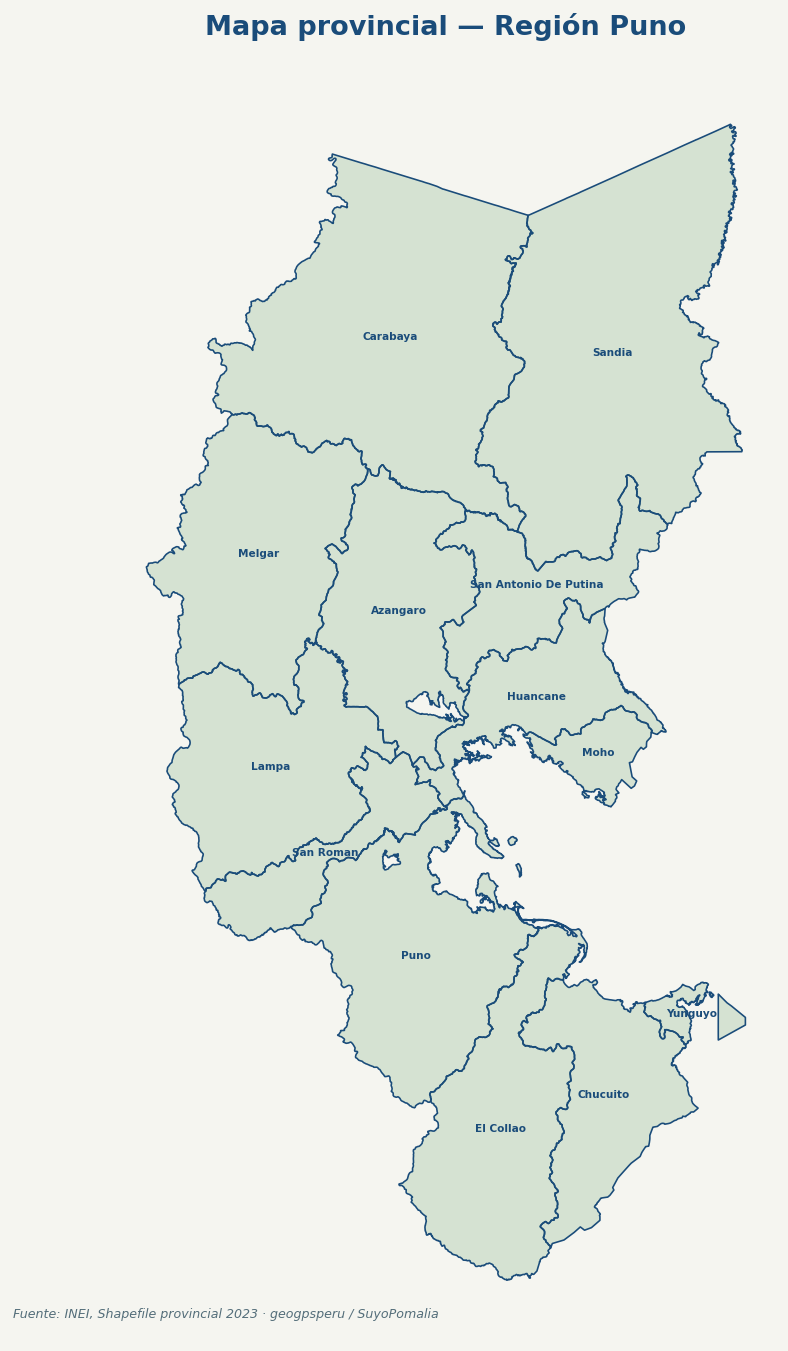

Cell 1 completada — mapa exportado.


In [16]:
# CELL 1: Shapefile INEI y mapa base provincial
"""
- Carga shapefile provincial INEI 2023.
- Detección automática de columnas departamental y provincial
  (distintas versiones del shapefile usan nombres distintos).
- Normaliza nombres de provincia a UPPER-STRIP para joins robustos.
- Genera mapa base con etiquetas de provincia.
"""
 
import geopandas as gpd
import pandas as pd
import numpy as np
 
# Carga
mapa_peru = gpd.read_file(RUTA_MAPA)
 
print("Shapefile cargado exitosamente.")
print(f"   CRS original      : {mapa_peru.crs}")
print(f"   Total registros   : {len(mapa_peru):,}")
print(f"   Columnas          : {list(mapa_peru.columns)}\n")
 
# Detección automática de columnas
def _detect_col(df: gpd.GeoDataFrame, candidates: list[str], label: str) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(
        f"No se encontró columna para '{label}'. "
        f"Candidatos buscados: {candidates}. "
        f"Columnas disponibles: {list(df.columns)}"
    )
 
COL_DEP  = _detect_col(mapa_peru, ['DEPARTAMEN', 'NOMBDEP',   'DEPARTAMENTO', 'NOM_DEP'],  'departamento')
COL_PROV = _detect_col(mapa_peru, ['PROVINCIA',  'NOMBPROV',  'NOM_PROV'],                 'provincia')
 
print(f"   Col. departamento : '{COL_DEP}'")
print(f"   Col. provincia    : '{COL_PROV}'")
 
# Filtro Puno + normalización
mapa_puno = (
    mapa_peru[mapa_peru[COL_DEP].str.strip().str.upper() == 'PUNO']
    .copy()
    .rename(columns={COL_PROV: 'PROVINCIA'})
)
mapa_puno['PROVINCIA'] = mapa_puno['PROVINCIA'].str.strip().str.upper()
 
N_PROV = len(mapa_puno)
print(f"\n   Provincias en Puno: {N_PROV}")
print(f"   {sorted(mapa_puno['PROVINCIA'].tolist())}")
 
# Mapa base provincial
fig, ax = plt.subplots(figsize=(9, 10.5))
 
mapa_puno.plot(
    ax=ax,
    color=PALETTE['accent'] + '28',
    edgecolor=PALETTE['primary'],
    linewidth=0.9,
)

for _, row in mapa_puno.iterrows():
    c = row.geometry.centroid
    ax.annotate(
        row['PROVINCIA'].title(),
        xy=(c.x, c.y), ha='center', va='center',
        fontsize=5.8, color=PALETTE['primary'], fontweight='bold',
    )
 
ax.set_title("Mapa provincial — Región Puno", color=PALETTE['primary'], pad=18)
ax.set_axis_off()
fig.text(0.13, 0.03,
         "Fuente: INEI, Shapefile provincial 2023 · geogpsperu / SuyoPomalia",
         fontsize=7, color=PALETTE['neutral'], style='italic')
 
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "01_mapa_provincial_puno.png")
plt.show()
print("Cell 1 completada — mapa exportado.")


CSV cargado: 13 filas × 2 columnas
Matching perfecto: todas las provincias tienen par.
   Provincias emparejadas: 13/13

   Rendimiento (Ton/Ha) — min: 0.600 | μ: 1.305 | max: 1.650 | σ: 0.279


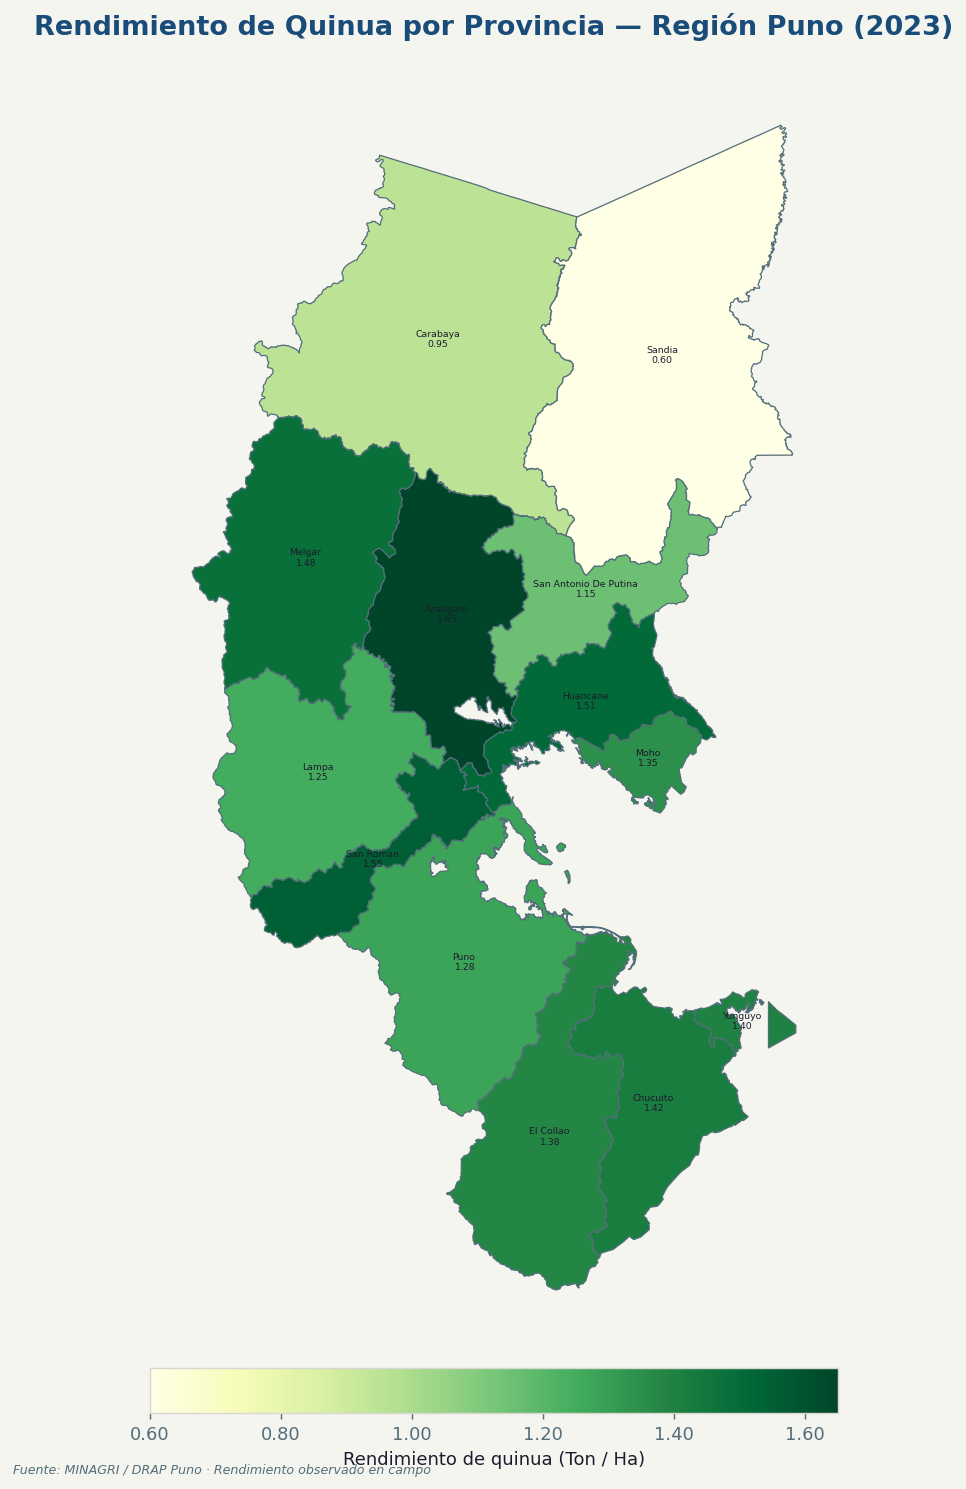

Cell 2 completada — mapa de rendimiento exportado.


In [17]:
# CELL 2: Integración de datos agrícolas y coroplético de rendimiento
"""
- Carga y valida el CSV de producción de quinua.
- Audita el matching antes del merge (evita pérdida silenciosa de filas).
- Genera mapa coroplético del rendimiento (Ton/Ha) con barra de color
  horizontal y etiquetas por provincia.
"""
 
from mpl_toolkits.axes_grid1 import make_axes_locatable
 
# Carga y validación del CSV
df_agricultura = pd.read_csv(RUTA_CSV)
df_agricultura['PROVINCIA'] = df_agricultura['PROVINCIA'].str.strip().str.upper()
 
if 'RENDIMIENTO_QUINUA' not in df_agricultura.columns:
    raise KeyError(
        f"Columna 'RENDIMIENTO_QUINUA' no encontrada. "
        f"Columnas disponibles: {list(df_agricultura.columns)}"
    )
 
print(f"CSV cargado: {len(df_agricultura)} filas × {df_agricultura.shape[1]} columnas")
 
# Auditoría de matching
prov_shp = set(mapa_puno['PROVINCIA'])
prov_csv = set(df_agricultura['PROVINCIA'])
 
sin_match_shp = prov_shp - prov_csv
sin_match_csv = prov_csv - prov_shp
 
if sin_match_shp:
    print(f"\nEn shapefile, sin match en CSV  : {sorted(sin_match_shp)}")
if sin_match_csv:
    print(f"En CSV, sin match en shapefile  : {sorted(sin_match_csv)}")
if not sin_match_shp and not sin_match_csv:
    print("Matching perfecto: todas las provincias tienen par.")
 
# Merge espacial
mapa_datos = mapa_puno.merge(df_agricultura, on='PROVINCIA', how='inner')
print(f"   Provincias emparejadas: {len(mapa_datos)}/{N_PROV}\n")
 
# Estadísticas descriptivas
rend = mapa_datos['RENDIMIENTO_QUINUA']
print(f"   Rendimiento (Ton/Ha) — min: {rend.min():.3f} | "
      f"μ: {rend.mean():.3f} | max: {rend.max():.3f} | σ: {rend.std():.3f}")
 
# Coroplético
fig, ax = plt.subplots(figsize=(10, 11.5))
divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="3.5%", pad=0.15)
 
mapa_datos.plot(
    column='RENDIMIENTO_QUINUA',
    cmap=CMAP_RENDIMIENTO,
    linewidth=0.7,
    ax=ax,
    edgecolor=PALETTE['neutral'],
    vmin=rend.min(), vmax=rend.max(),
    legend=True,
    legend_kwds={
        'label'      : 'Rendimiento de quinua (Ton / Ha)',
        'orientation': 'horizontal',
        'format'     : '%.2f',
    },
    cax=cax,
)
 
for _, row in mapa_datos.iterrows():
    c = row.geometry.centroid
    ax.annotate(
        f"{row['PROVINCIA'].title()}\n{row['RENDIMIENTO_QUINUA']:.2f}",
        xy=(c.x, c.y), ha='center', va='center',
        fontsize=5.2, color=PALETTE['text'],
    )
 
ax.set_title(
    f"Rendimiento de Quinua por Provincia — Región Puno ({AÑO_ANALISIS})",
    color=PALETTE['primary'], pad=18,
)
ax.set_axis_off()
fig.text(0.13, 0.01,
         "Fuente: MINAGRI / DRAP Puno · Rendimiento observado en campo",
         fontsize=7, color=PALETTE['neutral'], style='italic')
 
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_mapa_rendimiento_quinua.png")
plt.show()
print("Cell 2 completada — mapa de rendimiento exportado.")

In [18]:
# CELL 3: Extracción satelital — NASA POWER API (Ag Climatology)
"""
Descarga series mensuales de:
  · T2M         : Temperatura a 2 m (°C)
  · PRECTOTCORR : Precipitación corregida (mm/día → mm/mes usando días del mes)
  · RH2M        : Humedad relativa a 2 m (%)
 
Mejoras respecto al código original:
  · Backoff exponencial (hasta API_RETRIES intentos por provincia)
  · Conversión correcta de PRECTOTCORR: mm/día × días_del_mes → mm/mes acumulado
  · Filtrado de valores sentinel (-999.0) antes de calcular estadísticos
  · Centralización de centroides sobre CRS WGS84, sin mutar el GeoDataFrame fuente
  · Informe de completitud por provincia
"""
 
import requests
import time
import calendar
 
# Calcular centroides en WGS84
_mapa_geo = mapa_puno.to_crs(epsg=4326).copy()
_mapa_geo['LON'] = _mapa_geo.geometry.centroid.x.round(4)
_mapa_geo['LAT'] = _mapa_geo.geometry.centroid.y.round(4)
 
NASA_BASE   = "https://power.larc.nasa.gov/api/temporal/monthly/point"
NASA_PARAMS = "T2M,PRECTOTCORR,RH2M"
MESES       = [f"{AÑO_ANALISIS}{str(m).zfill(2)}" for m in range(1, 13)]
DIAS_MES    = [calendar.monthrange(AÑO_ANALISIS, m)[1] for m in range(1, 13)]
 
# Helpers
def _fetch_nasa(lat: float, lon: float, año: int, retries: int = API_RETRIES) -> dict | None:
    """GET a la API NASA POWER con backoff exponencial."""
    url = (
        f"{NASA_BASE}?parameters={NASA_PARAMS}&community=AG"
        f"&longitude={lon}&latitude={lat}"
        f"&format=JSON&start={año}&end={año}"
    )
    for attempt in range(1, retries + 1):
        try:
            r = requests.get(url, timeout=35)
            r.raise_for_status()
            return r.json()['properties']['parameter']
        except requests.exceptions.HTTPError:
            wait = 2 ** attempt
            print(f"        ↳ HTTP {r.status_code} — reintento {attempt}/{retries} en {wait}s...")
            time.sleep(wait)
        except requests.exceptions.RequestException as exc:
            print(f"        ↳ Error de red: {exc}")
            time.sleep(2 ** attempt)
    return None
 
 
def _serie_mensual(param: dict, meses: list[str], sentinel: float = -999.0) -> list[float | None]:
    """Retorna lista de 12 valores (None donde falta o es sentinel)."""
    return [
        param[m] if (m in param and param[m] != sentinel) else None
        for m in meses
    ]
 
 
def _media_validos(vals: list) -> float:
    """Media excluyendo None."""
    v = [x for x in vals if x is not None]
    return round(sum(v) / len(v), 3) if v else 0.0
 
 
# Descarga iterativa
print("Extracción satelital — NASA POWER (Ag Climatology)")
print("═" * 64)
 
datos_clima: list[dict] = []
n_total = len(_mapa_geo)
 
for i, (_, row) in enumerate(_mapa_geo.iterrows(), start=1):
    prov = row['PROVINCIA']
    lat, lon = row['LAT'], row['LON']
    print(f"  [{i:02d}/{n_total:02d}] {prov:<22} lat={lat:+.4f}  lon={lon:+.4f}", end="  ")
 
    raw = _fetch_nasa(lat, lon, AÑO_ANALISIS)
    if raw is None:
        print("FALLO — provincia omitida del dataset.")
        continue
 
    t2m_serie    = _serie_mensual(raw['T2M'],          MESES)
    precip_serie = _serie_mensual(raw['PRECTOTCORR'],  MESES)
    rh2m_serie   = _serie_mensual(raw['RH2M'],         MESES)
 
    # PRECTOTCORR [mm/día] × días_del_mes → mm/mes → suma anual
    precip_acum = sum(
        v * d for v, d in zip(precip_serie, DIAS_MES)
        if v is not None
    )
 
    datos_clima.append({
        'PROVINCIA'              : prov,
        'TEMP_PROMEDIO_C'        : _media_validos(t2m_serie),
        'PRECIPITACION_TOTAL_MM' : round(precip_acum, 2),
        'HUMEDAD_REL_PORCENTAJE' : _media_validos(rh2m_serie),
        'LAT_CENTROIDE'          : lat,
        'LON_CENTROIDE'          : lon,
    })
    n_meses_ok = sum(1 for v in t2m_serie if v is not None)
    print(f"Si ({n_meses_ok}/12 meses)")
    time.sleep(API_DELAY_S)
 
# Construcción del dataset maestro
df_clima = pd.DataFrame(datos_clima)
 
if df_clima.empty:
    raise RuntimeError(
        "Sin datos climáticos. Verifica conexión a internet y que la API "
        "NASA POWER esté disponible."
    )
 
mapa_dataset_final = mapa_datos.merge(df_clima, on='PROVINCIA', how='inner')
 
print("\n" + "═" * 64)
print(f"Extracción completada: {len(df_clima)}/{n_total} provincias.")
print(f"\n{'PROVINCIA':<22} {'TEMP(°C)':>9} {'PRECIP(mm/año)':>15} {'HR(%)':>8}")
print("─" * 57)
for _, r in df_clima.iterrows():
    print(f"  {r['PROVINCIA']:<20} {r['TEMP_PROMEDIO_C']:>9.2f} "
          f"{r['PRECIPITACION_TOTAL_MM']:>15.1f} {r['HUMEDAD_REL_PORCENTAJE']:>8.1f}")
 
print(f"\n   Dataset maestro: {mapa_dataset_final.shape[0]} filas × "
      f"{mapa_dataset_final.shape[1]} columnas")
print("Cell 3 completada.")

Extracción satelital — NASA POWER (Ag Climatology)
════════════════════════════════════════════════════════════════
  [01/13] PUNO                   lat=-16.0866  lon=-70.0806  Si (12/12 meses)
  [02/13] AZANGARO               lat=-14.8054  lon=-70.1470  Si (12/12 meses)
  [03/13] CARABAYA               lat=-13.7918  lon=-70.1794  Si (12/12 meses)
  [04/13] CHUCUITO               lat=-16.6055  lon=-69.3577  Si (12/12 meses)
  [05/13] EL COLLAO              lat=-16.7301  lon=-69.7561  Si (12/12 meses)
  [06/13] HUANCANE               lat=-15.1260  lon=-69.6159  Si (12/12 meses)
  [07/13] LAMPA                  lat=-15.3870  lon=-70.6401  Si (12/12 meses)
  [08/13] MELGAR                 lat=-14.5966  lon=-70.6862  Si (12/12 meses)
  [09/13] MOHO                   lat=-15.3351  lon=-69.3803  Si (12/12 meses)
  [10/13] SAN ANTONIO DE PUTINA  lat=-14.7117  lon=-69.6156  Si (12/12 meses)
  [11/13] SAN ROMAN              lat=-15.7063  lon=-70.4297  Si (12/12 meses)
  [12/13] SANDIA          

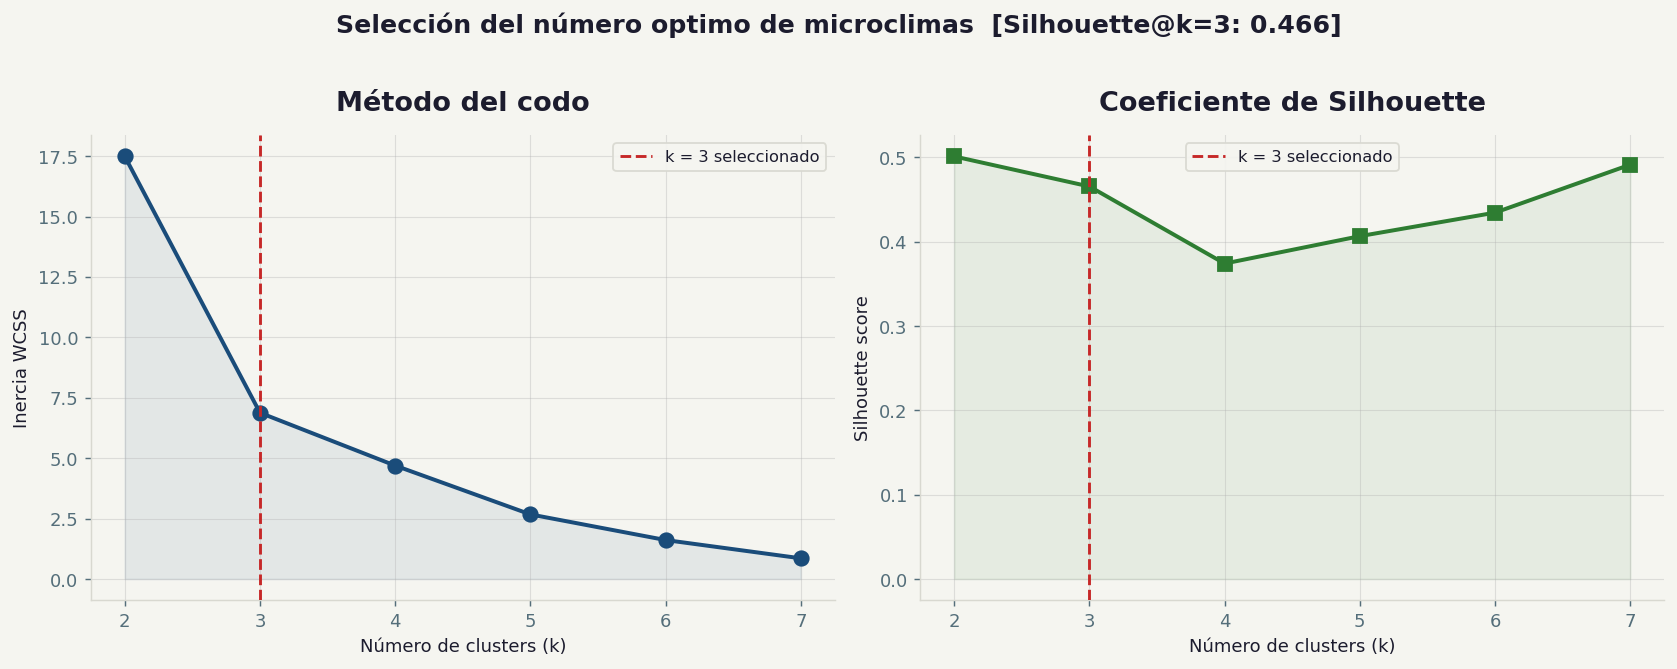

Centroides en escala original:
            TEMP_PROMEDIO_C  PRECIPITACION_TOTAL_MM  HUMEDAD_REL_PORCENTAJE    MICROCLIMA
CLUSTER_ID                                                                               
0                     16.41                 1845.15                   86.12  Microclima A
1                      7.99                  707.45                   60.83  Microclima B
2                      7.30                 1215.85                   79.19  Microclima C


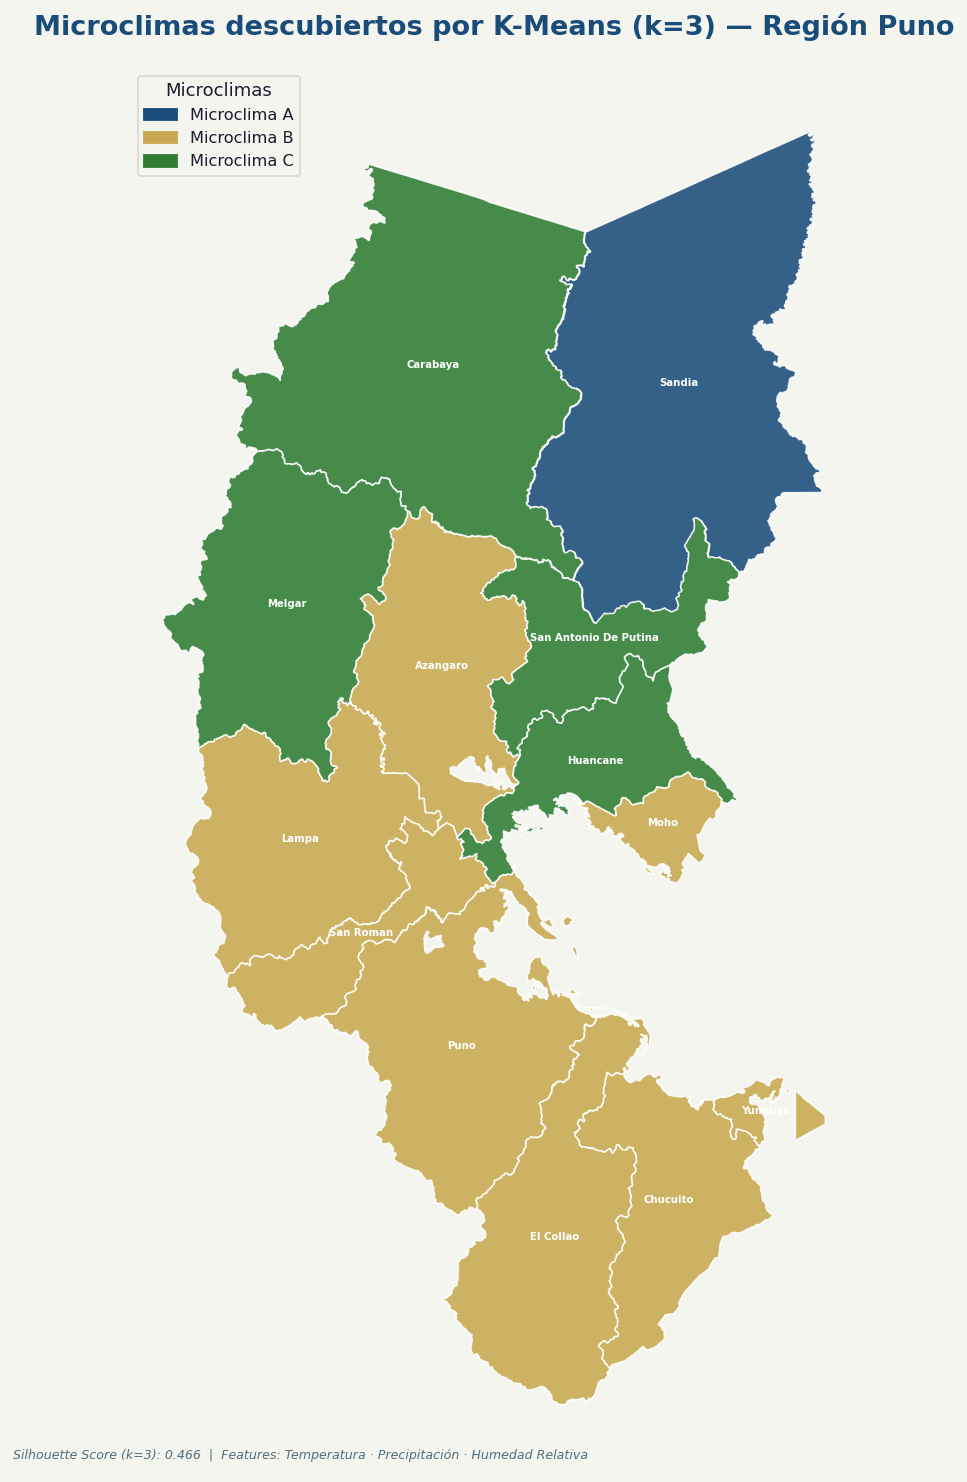


Perfil estadístico por microclima:


TEMP_PROMEDIO_C        PRECIPITACION_TOTAL_MM           \
                        mean    std                   mean      std   
MICROCLIMA                                                            
Microclima A          16.413    NaN               1845.150      NaN   
Microclima B           7.994  1.131                707.446  172.761   
Microclima C           7.298  1.351               1215.847  124.057   

             HUMEDAD_REL_PORCENTAJE       RENDIMIENTO_QUINUA         
                               mean   std               mean    std  
MICROCLIMA                                                           
Microclima A                 86.118   NaN              0.600    NaN  
Microclima B                 60.828  5.26              1.410  0.133  
Microclima C                 79.193  7.12              1.272  0.270

Cell 4 completada.


In [19]:
# CELL 4: Descubrimiento de microclimas — K-Means clustering
"""
Pipeline completo de clustering:
  1. Estandarización (StandardScaler) para igualar escalas entre variables.
  2. Selección del k óptimo: método del codo (WCSS) + Silhouette Score.
  3. K-Means con n_init=20 para convergencia estable.
  4. Nomenclatura DATA-DRIVEN: los nombres de microclima se derivan de los
     centroides en escala original, comparados con la media regional.
     (Evita el bug del código original donde el mapeo 0→'Tipo A' es arbitrario
     y no reproducible entre ejecuciones con distinto estado del optimizador.)
  5. Mapa coroplético discreto + perfil estadístico de cada microclima.
"""
 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
 
FEATURES_CLIMA = ['TEMP_PROMEDIO_C', 'PRECIPITACION_TOTAL_MM', 'HUMEDAD_REL_PORCENTAJE']
X_clima = mapa_dataset_final[FEATURES_CLIMA].copy()
 
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_clima)
 
# 1. Selección del k óptimo
k_range     = range(2, min(8, len(mapa_dataset_final)))
inertias    = []
silhouettes = []
 
for k in k_range:
    _km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=15)
    _lbl = _km.fit_predict(X_scaled)
    inertias.append(_km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, _lbl))
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
 
ax1.plot(list(k_range), inertias, 'o-', color=PALETTE['primary'], lw=2.2, ms=8, zorder=3)
ax1.axvline(N_MICROCLIMAS, color=PALETTE['danger'], ls='--', lw=1.6,
            label=f'k = {N_MICROCLIMAS} seleccionado', zorder=4)
ax1.fill_between(list(k_range), inertias,
                 alpha=0.08, color=PALETTE['primary'])
ax1.set_xlabel("Número de clusters (k)")
ax1.set_ylabel("Inercia WCSS")
ax1.set_title("Método del codo")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.35, lw=0.6)
 
ax2.plot(list(k_range), silhouettes, 's-', color=PALETTE['accent'], lw=2.2, ms=8, zorder=3)
ax2.axvline(N_MICROCLIMAS, color=PALETTE['danger'], ls='--', lw=1.6,
            label=f'k = {N_MICROCLIMAS} seleccionado', zorder=4)
ax2.fill_between(list(k_range), silhouettes,
                 alpha=0.08, color=PALETTE['accent'])
ax2.set_xlabel("Número de clusters (k)")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Coeficiente de Silhouette")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.35, lw=0.6)
 
sil_opt = silhouettes[N_MICROCLIMAS - 2]
fig.suptitle(
    f"Selección del número optimo de microclimas  "
    f"[Silhouette@k={N_MICROCLIMAS}: {sil_opt:.3f}]",
    fontsize=14, fontweight='bold', y=1.02,
)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "04a_elbow_silhouette.png")
plt.show()
 
# 2. K-Means final
kmeans = KMeans(n_clusters=N_MICROCLIMAS, random_state=RANDOM_STATE, n_init=20)
mapa_dataset_final['CLUSTER_ID'] = kmeans.fit_predict(X_scaled)
 
# 3. Nomenclatura data-driven
centros = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=FEATURES_CLIMA,
)
centros.index.name = 'CLUSTER_ID'
 
T_med = centros['TEMP_PROMEDIO_C'].mean()
P_med = centros['PRECIPITACION_TOTAL_MM'].mean()
H_med = centros['HUMEDAD_REL_PORCENTAJE'].mean()
 
_NOMBRES_POOL = {
    (True,  True ):  'Altiplánico Frío-Húmedo',
    (True,  False):  'Altiplánico Frío-Seco',
    (False, True ):  'Templado Sub-húmedo',
    (False, False):  'Templado Semiárido',
}
 
def _nombre_cluster(row: pd.Series) -> str:
    frio   = row['TEMP_PROMEDIO_C']          < T_med
    humedo = row['PRECIPITACION_TOTAL_MM']   > P_med
    return _NOMBRES_POOL[(frio, humedo)]
 
centros['MICROCLIMA'] = centros.apply(_nombre_cluster, axis=1)

if centros['MICROCLIMA'].nunique() < N_MICROCLIMAS:
    centros['MICROCLIMA'] = [f"Microclima {chr(65+i)}" for i in range(N_MICROCLIMAS)]
 
mapa_dataset_final['MICROCLIMA'] = (
    mapa_dataset_final['CLUSTER_ID'].map(centros['MICROCLIMA'].to_dict())
)
 
print("Centroides en escala original:")
print(centros[['TEMP_PROMEDIO_C', 'PRECIPITACION_TOTAL_MM',
               'HUMEDAD_REL_PORCENTAJE', 'MICROCLIMA']].round(2).to_string())
 
# 4. Mapa de microclimas
nombres_micro = centros['MICROCLIMA'].tolist()
colores_micro = {n: MICRO_COLORS[i] for i, n in enumerate(nombres_micro)}
 
fig, ax = plt.subplots(figsize=(10, 11.5))
 
for nombre, grupo in mapa_dataset_final.groupby('MICROCLIMA'):
    grupo.plot(ax=ax, color=colores_micro[nombre],
               edgecolor='white', linewidth=0.9, label=nombre, alpha=0.88)
 
for _, row in mapa_dataset_final.iterrows():
    c = row.geometry.centroid
    ax.annotate(row['PROVINCIA'].title(), xy=(c.x, c.y),
                ha='center', va='center', fontsize=5.6,
                color='white', fontweight='bold')
 
patches = [mpatches.Patch(color=colores_micro[n], label=n) for n in nombres_micro]
ax.legend(handles=patches, loc='upper left', fontsize=9,
          title='Microclimas', title_fontsize=10, framealpha=0.92)
ax.set_title(
    f"Microclimas descubiertos por K-Means (k={N_MICROCLIMAS}) — Región Puno",
    color=PALETTE['primary'], pad=18,
)
ax.set_axis_off()
fig.text(0.13, 0.02,
         f"Silhouette Score (k={N_MICROCLIMAS}): {sil_opt:.3f}  |  "
         f"Features: Temperatura · Precipitación · Humedad Relativa",
         fontsize=7, color=PALETTE['neutral'], style='italic')
 
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "04b_mapa_microclimas.png")
plt.show()
 
# 5. Perfil estadístico
perfil = mapa_dataset_final.groupby('MICROCLIMA')[
    FEATURES_CLIMA + ['RENDIMIENTO_QUINUA']
].agg(['mean', 'std']).round(3)
 
print("\nPerfil estadístico por microclima:")
display(perfil)
print("Cell 4 completada.")
 

Random Forest — Evaluación de generalización
RMSE_LOO  : 0.2328 Ton/Ha
MAE_LOO   : 0.1739 Ton/Ha
R²_LOO    : 0.2441
OOB R²    : 0.2723  (estimado por bootstrap)
n = 13 provincias │ LOO-CV: única métrica válida


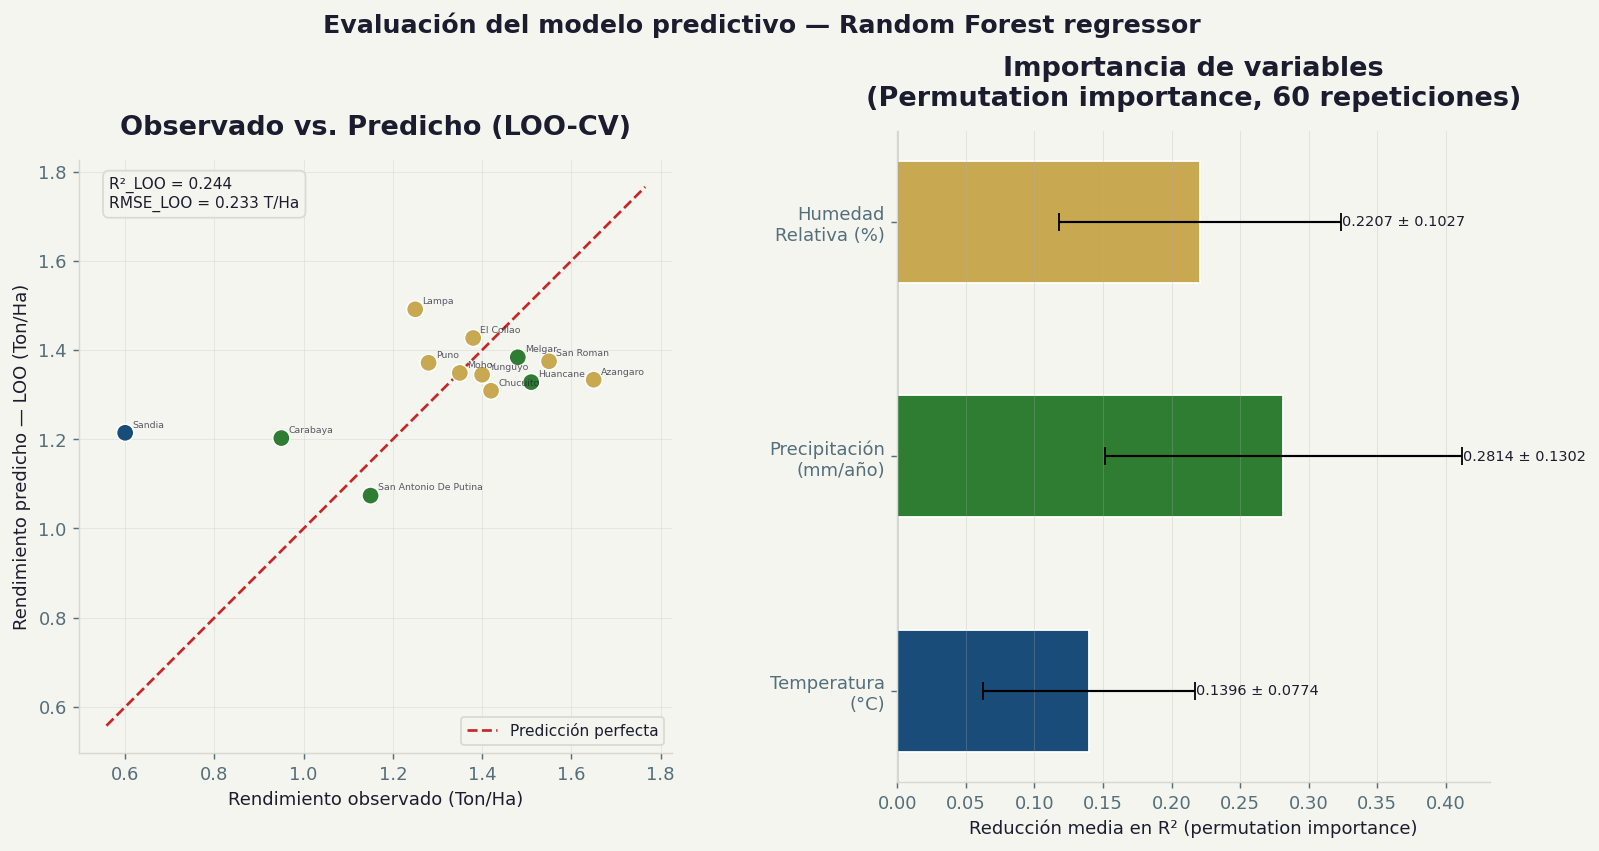


══════════════════════════════════════════════════════════
  SIMULACIÓN El Niño — Puno
══════════════════════════════════════════════════════════
  Clima 2023 (normal)                : 1.344 Ton/Ha
  Escenario El Niño (+2 °C, −30%↓)  : 1.314 Ton/Ha
  Impacto proyectado                 : −2.3% en rendimiento
══════════════════════════════════════════════════════════
Cell 5 completada.


In [20]:
# CELL 5 │ Modelo Predictivo — Random Forest + LOO Cross-Validation
"""
NOTA METODOLÓGICA: n ≈ 13 provincias.
  · Train/Test split convencional es inviable: cualquier split deja ~2–3 muestras
    de test, produciendo métricas con varianza enorme.
  · Se usa Leave-One-Out CV (LOO-CV): en cada fold, el modelo se entrena con
    n-1 provincias y predice la provincia omitida. Métrica más honesta para n pequeño.
  · El modelo FINAL se re-entrena sobre TODOS los datos para producir predicciones
    y mapa de riesgo. Esto no implica data leakage porque LOO-CV ya evaluó la
    capacidad de generalización.
  · Importancia de variables: Permutation Importance (más robusta que MDI para n pequeño,
    ya que MDI está sesgado hacia variables con alta cardinalidad o escala numérica).
 
LIMITACIÓN EXPLÍCITA: con n=13 y RF, el modelo tiende a memorizar los datos de
entrenamiento (R²_train ≈ 1.0). La métrica válida es R²_LOO y RMSE_LOO.
"""
 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import numpy as np

TARGET = 'RENDIMIENTO_QUINUA'

X = mapa_dataset_final[FEATURES_CLIMA].to_numpy(dtype=float)
y = mapa_dataset_final[TARGET].to_numpy(dtype=float)

# Modelo final
rf_model = RandomForestRegressor(
    n_estimators    = 500,
    max_features    = 'sqrt',
    min_samples_leaf= 2,
    bootstrap       = True,
    oob_score       = True,
    random_state    = RANDOM_STATE,
    n_jobs          = -1,
)
rf_model.fit(X, y)

# LOO Cross-Validation
loo = LeaveOneOut()
y_pred_loo = cross_val_predict(rf_model, X, y, cv=loo)

rmse_loo = float(np.sqrt(mean_squared_error(y, y_pred_loo)))
mae_loo  = float(mean_absolute_error(y, y_pred_loo))
r2_loo   = float(r2_score(y, y_pred_loo))
oob_r2   = float(rf_model.oob_score_)

print("Random Forest — Evaluación de generalización")
print(f"RMSE_LOO  : {rmse_loo:.4f} Ton/Ha")
print(f"MAE_LOO   : {mae_loo:.4f} Ton/Ha")
print(f"R²_LOO    : {r2_loo:.4f}")
print(f"OOB R²    : {oob_r2:.4f}  (estimado por bootstrap)")
print(f"n = {len(y)} provincias │ LOO-CV: única métrica válida")

# Permutation importance
perm_imp   = permutation_importance(rf_model, X, y, n_repeats=60, random_state=RANDOM_STATE)
perm_means = perm_imp.importances_mean  # type: ignore
perm_stds  = perm_imp.importances_std   # type: ignore
 
# Figura: 2 paneles
fig = plt.figure(figsize=(14, 6.5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38)
 
# Panel izquierdo: Observado vs. Predicho (LOO)
ax1 = fig.add_subplot(gs[0])
sc = ax1.scatter(y, y_pred_loo,
                 c=[colores_micro[m] for m in mapa_dataset_final['MICROCLIMA']],
                 s=90, zorder=3, edgecolors='white', lw=0.8)
lims = [min(y.min(), y_pred_loo.min()) * 0.93,
        max(y.max(), y_pred_loo.max()) * 1.07]
ax1.plot(lims, lims, '--', color=PALETTE['danger'], lw=1.5, label='Predicción perfecta')
ax1.set_xlabel("Rendimiento observado (Ton/Ha)")
ax1.set_ylabel("Rendimiento predicho — LOO (Ton/Ha)")
ax1.set_title("Observado vs. Predicho (LOO-CV)")
ax1.legend(fontsize=8.5)
ax1.grid(True, alpha=0.25, lw=0.5)
ax1.set_aspect('equal', 'box')

for i, (xi, yi) in enumerate(zip(y, y_pred_loo)):
    prov_label = mapa_dataset_final['PROVINCIA'].iloc[i].title()
    ax1.annotate(prov_label, (xi, yi), fontsize=5.2, alpha=0.72,
                 xytext=(4, 3), textcoords='offset points')
 
ax1.text(0.05, 0.92, f"R²_LOO = {r2_loo:.3f}\nRMSE_LOO = {rmse_loo:.3f} T/Ha",
         transform=ax1.transAxes, fontsize=8.5,
         bbox=dict(boxstyle='round,pad=0.4', facecolor=PALETTE['bg'],
                   edgecolor=PALETTE['grid'], alpha=0.9))
 
# Panel derecho: Permutation importance
ax2 = fig.add_subplot(gs[1])
feat_labels = ['Temperatura\n(°C)', 'Precipitación\n(mm/año)', 'Humedad\nRelativa (%)']
imp_colors  = [PALETTE['primary'], PALETTE['accent'], PALETTE['secondary']]
 
bars = ax2.barh(feat_labels, perm_means,
                xerr=perm_stds, color=imp_colors,
                edgecolor='white', height=0.52, capsize=5, error_kw={'lw': 1.2})
ax2.set_xlabel("Reducción media en R² (permutation importance)")
ax2.set_title("Importancia de variables\n(Permutation importance, 60 repeticiones)")
ax2.grid(True, alpha=0.3, axis='x', lw=0.5)
ax2.axvline(0, color=PALETTE['neutral'], lw=0.8)
 
for bar, val, std in zip(bars, perm_means, perm_stds):
    ax2.text(max(val, 0) + std + 0.001,
             bar.get_y() + bar.get_height() / 2,
             f"{val:.4f} ± {std:.4f}",
             va='center', fontsize=8, color=PALETTE['text'])
 
fig.suptitle(
    "Evaluación del modelo predictivo — Random Forest regressor",
    fontsize=14, fontweight='bold', y=1.02,
)
plt.savefig(OUTPUT_DIR / "05_random_forest_evaluacion.png")
plt.show()
 
# Simulación puntual: Fenómeno del niño en provincia de Puno
_puno_row = mapa_dataset_final[mapa_dataset_final['PROVINCIA'] == 'PUNO']
if _puno_row.empty:
    print("Provincia 'PUNO' no hallada. Usando la de mayor rendimiento.")
    _puno_row = mapa_dataset_final.nlargest(1, TARGET)
 
X_puno_normal = _puno_row[FEATURES_CLIMA].values.copy()
X_puno_nino   = X_puno_normal.copy()
X_puno_nino[0, 0] += 2.0
X_puno_nino[0, 1] *= 0.70
 
pred_normal = rf_model.predict(X_puno_normal)[0]
pred_nino   = rf_model.predict(X_puno_nino)[0]
caida_pct   = (pred_normal - pred_nino) / pred_normal * 100
 
_prov = _puno_row['PROVINCIA'].values[0].title()
print(f"\n{'═'*58}")
print(f"  SIMULACIÓN El Niño — {_prov}")
print(f"{'═'*58}")
print(f"  Clima 2023 (normal)                : {pred_normal:.3f} Ton/Ha")
print(f"  Escenario El Niño (+2 °C, −30%↓)  : {pred_nino:.3f} Ton/Ha")
print(f"  Impacto proyectado                 : −{caida_pct:.1f}% en rendimiento")
print(f"{'═'*58}")
print("Cell 5 completada.")


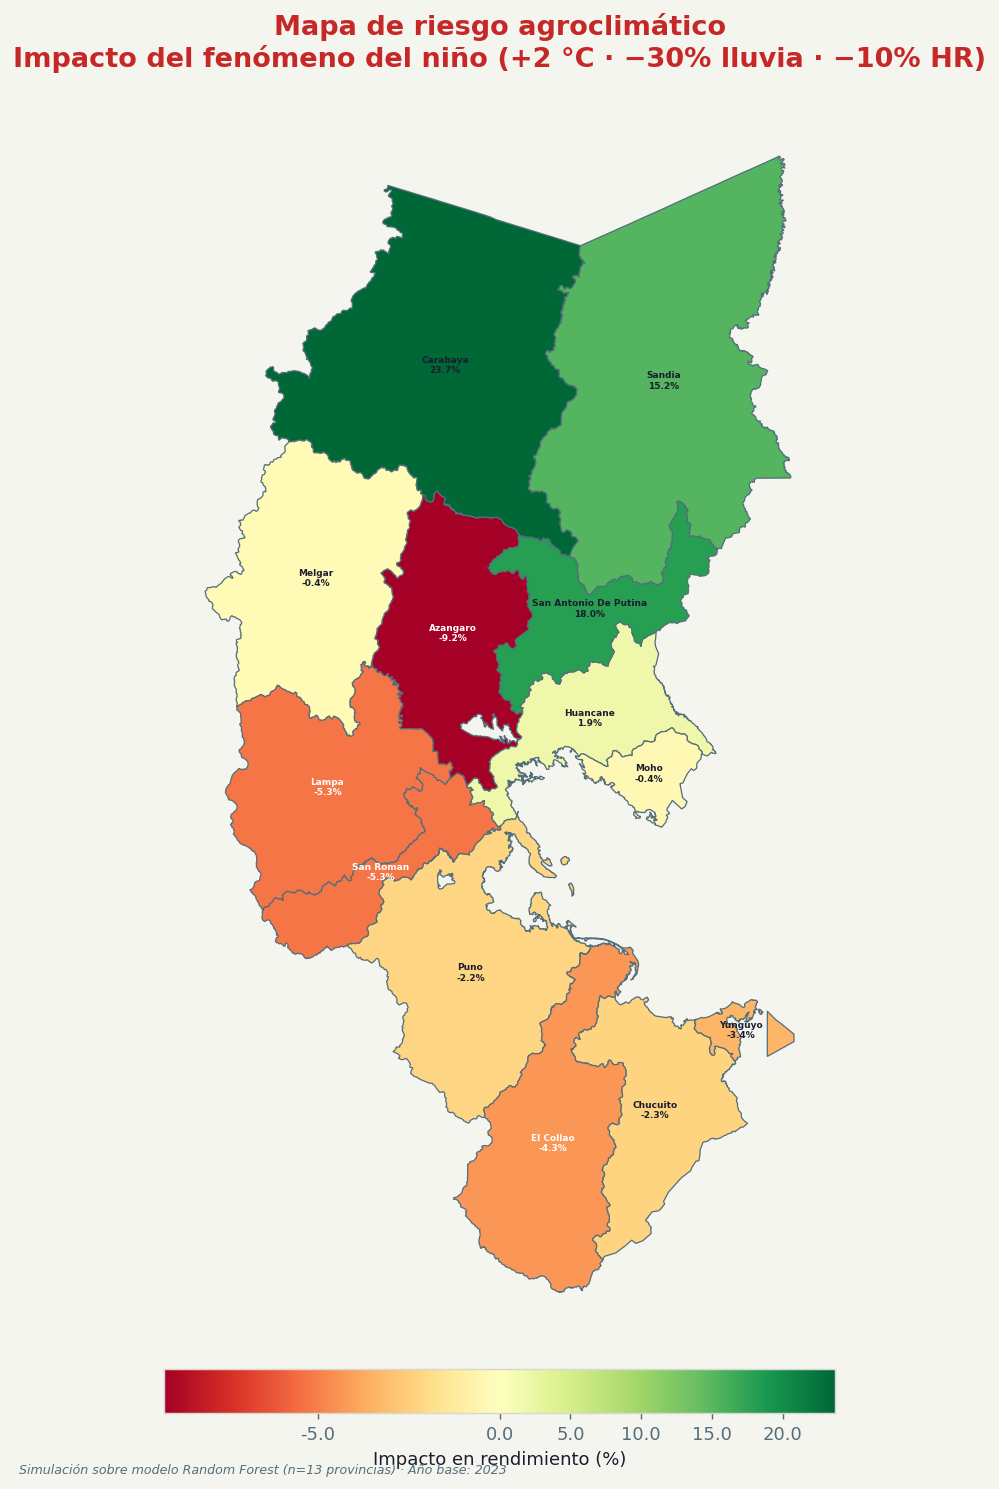


PROVINCIAS EN ALERTA — Mayor pérdida proyectada:
────────────────────────────────────────────────────────────


,Provincia,Rend. Normal (T/Ha),Rend. El Niño (T/Ha),Impacto (%)
1,AZANGARO,1.457,1.323,-9.22%
2,LAMPA,1.417,1.342,-5.32%
3,SAN ROMAN,1.417,1.342,-5.32%
4,EL COLLAO,1.403,1.342,-4.35%
5,YUNGUYO,1.371,1.324,-3.42%
6,CHUCUITO,1.346,1.315,-2.30%
7,PUNO,1.344,1.315,-2.19%


Cell 6 completada.


In [21]:
# CELL 6: Simulación regional — Mapa de riesgo climático
"""
Aplica el escenario del niño sobre TODAS las provincias:
  · Anomalía térmica     : +2 °C
  · Anomalía pluviométrica: −30%
  · Anomalía de humedad  : −10%
 
Se almacenan columnas separadas para el escenario adverso (sin sobrescribir
las variables originales) para mantener el dataset maestro íntegro.
 
TwoSlopeNorm centra la paleta RdYlGn en 0%:
  · Verde = impacto positivo o neutro
  · Rojo  = pérdida
"""
 
from matplotlib.colors import TwoSlopeNorm
 
mapa_simulacion = mapa_dataset_final.copy()

mapa_simulacion['TEMP_NINO']    = mapa_simulacion['TEMP_PROMEDIO_C']          + 2.0
mapa_simulacion['PRECIP_NINO']  = mapa_simulacion['PRECIPITACION_TOTAL_MM']   * 0.70
mapa_simulacion['HUMEDAD_NINO'] = mapa_simulacion['HUMEDAD_REL_PORCENTAJE']   * 0.90
 
X_actual   = mapa_dataset_final[FEATURES_CLIMA].values
X_nino_reg = mapa_simulacion[['TEMP_NINO', 'PRECIP_NINO', 'HUMEDAD_NINO']].values
 
mapa_simulacion['PRED_NORMAL'] = rf_model.predict(X_actual)
mapa_simulacion['PRED_NINO']   = rf_model.predict(X_nino_reg)
mapa_simulacion['IMPACTO_PCT'] = (
    (mapa_simulacion['PRED_NINO'] - mapa_simulacion['PRED_NORMAL'])
    / mapa_simulacion['PRED_NORMAL'] * 100
)
 
# Mapa de riesgo
fig, ax = plt.subplots(figsize=(10, 11.5))
divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="3.5%", pad=0.15)
 
imp = mapa_simulacion['IMPACTO_PCT']
_vmin, _vmax = imp.min(), imp.max()
_vmax_pos = max(_vmax, 0.01)
norm_riesgo = TwoSlopeNorm(vmin=_vmin, vcenter=0.0, vmax=_vmax_pos)
 
mapa_simulacion.plot(
    column='IMPACTO_PCT',
    cmap=CMAP_RIESGO,
    norm=norm_riesgo,
    linewidth=0.7,
    ax=ax,
    edgecolor=PALETTE['neutral'],
    legend=True,
    legend_kwds={
        'label'      : 'Impacto en rendimiento (%)',
        'orientation': 'horizontal',
        'format'     : '%.1f',
    },
    cax=cax,
)
 
for _, row in mapa_simulacion.iterrows():
    c = row.geometry.centroid
    txt_color = 'white' if row['IMPACTO_PCT'] < -4 else PALETTE['text']
    ax.annotate(
        f"{row['PROVINCIA'].title()}\n{row['IMPACTO_PCT']:.1f}%",
        xy=(c.x, c.y), ha='center', va='center',
        fontsize=5.0, color=txt_color, fontweight='bold',
    )
 
ax.set_title(
    "Mapa de riesgo agroclimático\n"
    "Impacto del fenómeno del niño (+2 °C · −30% lluvia · −10% HR)",
    color=PALETTE['danger'], pad=18,
)
ax.set_axis_off()
fig.text(0.13, 0.01,
         f"Simulación sobre modelo Random Forest (n={len(mapa_simulacion)} provincias) · "
         f"Año base: {AÑO_ANALISIS}",
         fontsize=7, color=PALETTE['neutral'], style='italic')
 
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "06_mapa_riesgo_nino.png")
plt.show()
 
# Ranking de vulnerabilidad
print("\nPROVINCIAS EN ALERTA — Mayor pérdida proyectada:")
print("─" * 60)
ranking = (
    mapa_simulacion[['PROVINCIA', 'PRED_NORMAL', 'PRED_NINO', 'IMPACTO_PCT']]
    .sort_values('IMPACTO_PCT')
    .head(7)
    .reset_index(drop=True)
)
ranking.index += 1
ranking.columns = ['Provincia', 'Rend. Normal (T/Ha)', 'Rend. El Niño (T/Ha)', 'Impacto (%)']
display(
    ranking.style
    .format({'Rend. Normal (T/Ha)': '{:.3f}',
             'Rend. El Niño (T/Ha)': '{:.3f}',
             'Impacto (%)': '{:.2f}%'})
    .background_gradient(subset=['Impacto (%)'], cmap='Reds_r')
    .set_caption("Top 7 provincias más vulnerables al Fenómeno del Niño")
)
print("Cell 6 completada.")

In [22]:
# CELL 7: Mapa interactivo — Plotly express scatter mapbox
"""
Genera un mapa scatter interactivo Plotly sobre tiles Carto-Positron
(sin API key de Mapbox).
 
FIX respecto al código original:
  · px.scatter_map → px.scatter_mapbox (compatible con Plotly < 5.15)
  · map_style      → mapbox_style
  · Se proyecta mapa_simulacion a WGS84 y se extraen centroides correctamente.
  · color_continuous_midpoint=0 centra RdYlGn en impacto neutro.
  · Exportación a HTML autónomo para distribución.
"""
 
import plotly.express as px
 
# Proyectar y extraer centroides
_sim_geo = mapa_simulacion.to_crs(epsg=4326).copy()
_sim_geo['LON'] = _sim_geo.geometry.centroid.x.round(5)
_sim_geo['LAT'] = _sim_geo.geometry.centroid.y.round(5)

df_plot = pd.DataFrame(_sim_geo.drop(columns='geometry'))
 
# Figura interactiva
fig_iact = px.scatter_mapbox(
    df_plot,
    lat='LAT', lon='LON',
    color='IMPACTO_PCT',
    size='RENDIMIENTO_QUINUA',
    size_max=32,
    hover_name='PROVINCIA',
    hover_data={
        'TEMP_PROMEDIO_C'        : ':.2f',
        'PRECIPITACION_TOTAL_MM' : ':.1f',
        'HUMEDAD_REL_PORCENTAJE' : ':.1f',
        'PRED_NORMAL'            : ':.3f',
        'PRED_NINO'              : ':.3f',
        'IMPACTO_PCT'            : ':.2f',
        'MICROCLIMA'             : True,
        'LAT'                    : False,
        'LON'                    : False,
    },
    color_continuous_scale   = 'RdYlGn',
    color_continuous_midpoint= 0,
    labels={
        'IMPACTO_PCT'            : 'Impacto del niño (%)',
        'RENDIMIENTO_QUINUA'     : 'Rendimiento (Ton/Ha)',
        'TEMP_PROMEDIO_C'        : 'Temp. media (°C)',
        'PRECIPITACION_TOTAL_MM' : 'Precipitación (mm/año)',
        'HUMEDAD_REL_PORCENTAJE' : 'Humedad relativa (%)',
        'PRED_NORMAL'            : 'Pred. Normal (T/Ha)',
        'PRED_NINO'              : 'Pred. El Niño (T/Ha)',
        'MICROCLIMA'             : 'Microclima',
    },
    zoom         = 6.2,  # type: ignore
    center       = {'lat': -14.5, 'lon': -70.0},
    mapbox_style = 'carto-positron',
    opacity      = 0.88,
    title=(
        '<b>AgroSpatial-ML | Rendimiento de quinua y riesgo climático '
        f'— Región Puno {AÑO_ANALISIS}</b>'
    ),
)
 
fig_iact.update_layout(
    margin={'r': 0, 't': 52, 'l': 0, 'b': 0},
    coloraxis_colorbar={
        'title'     : 'Impacto<br>El Niño (%)',
        'tickformat': '.1f',
        'thickness' : 15,
        'len'       : 0.6,
    },
    title_font_size = 15,
    font_family     = 'Arial',
    paper_bgcolor   = '#FFFFFF',
)
 
_html_iact = OUTPUT_DIR / "07_mapa_interactivo.html"
fig_iact.write_html(str(_html_iact))
fig_iact.show()
print(f"Cell 7 completada — Mapa interactivo: {_html_iact}")

Cell 7 completada — Mapa interactivo: G:\2026\Trabajos\Agriapatial-ML descubrimiento de microclimas y predicción de rendimientos mediante inteligencia artificial\spatial-agri-production\outputs\07_mapa_interactivo.html


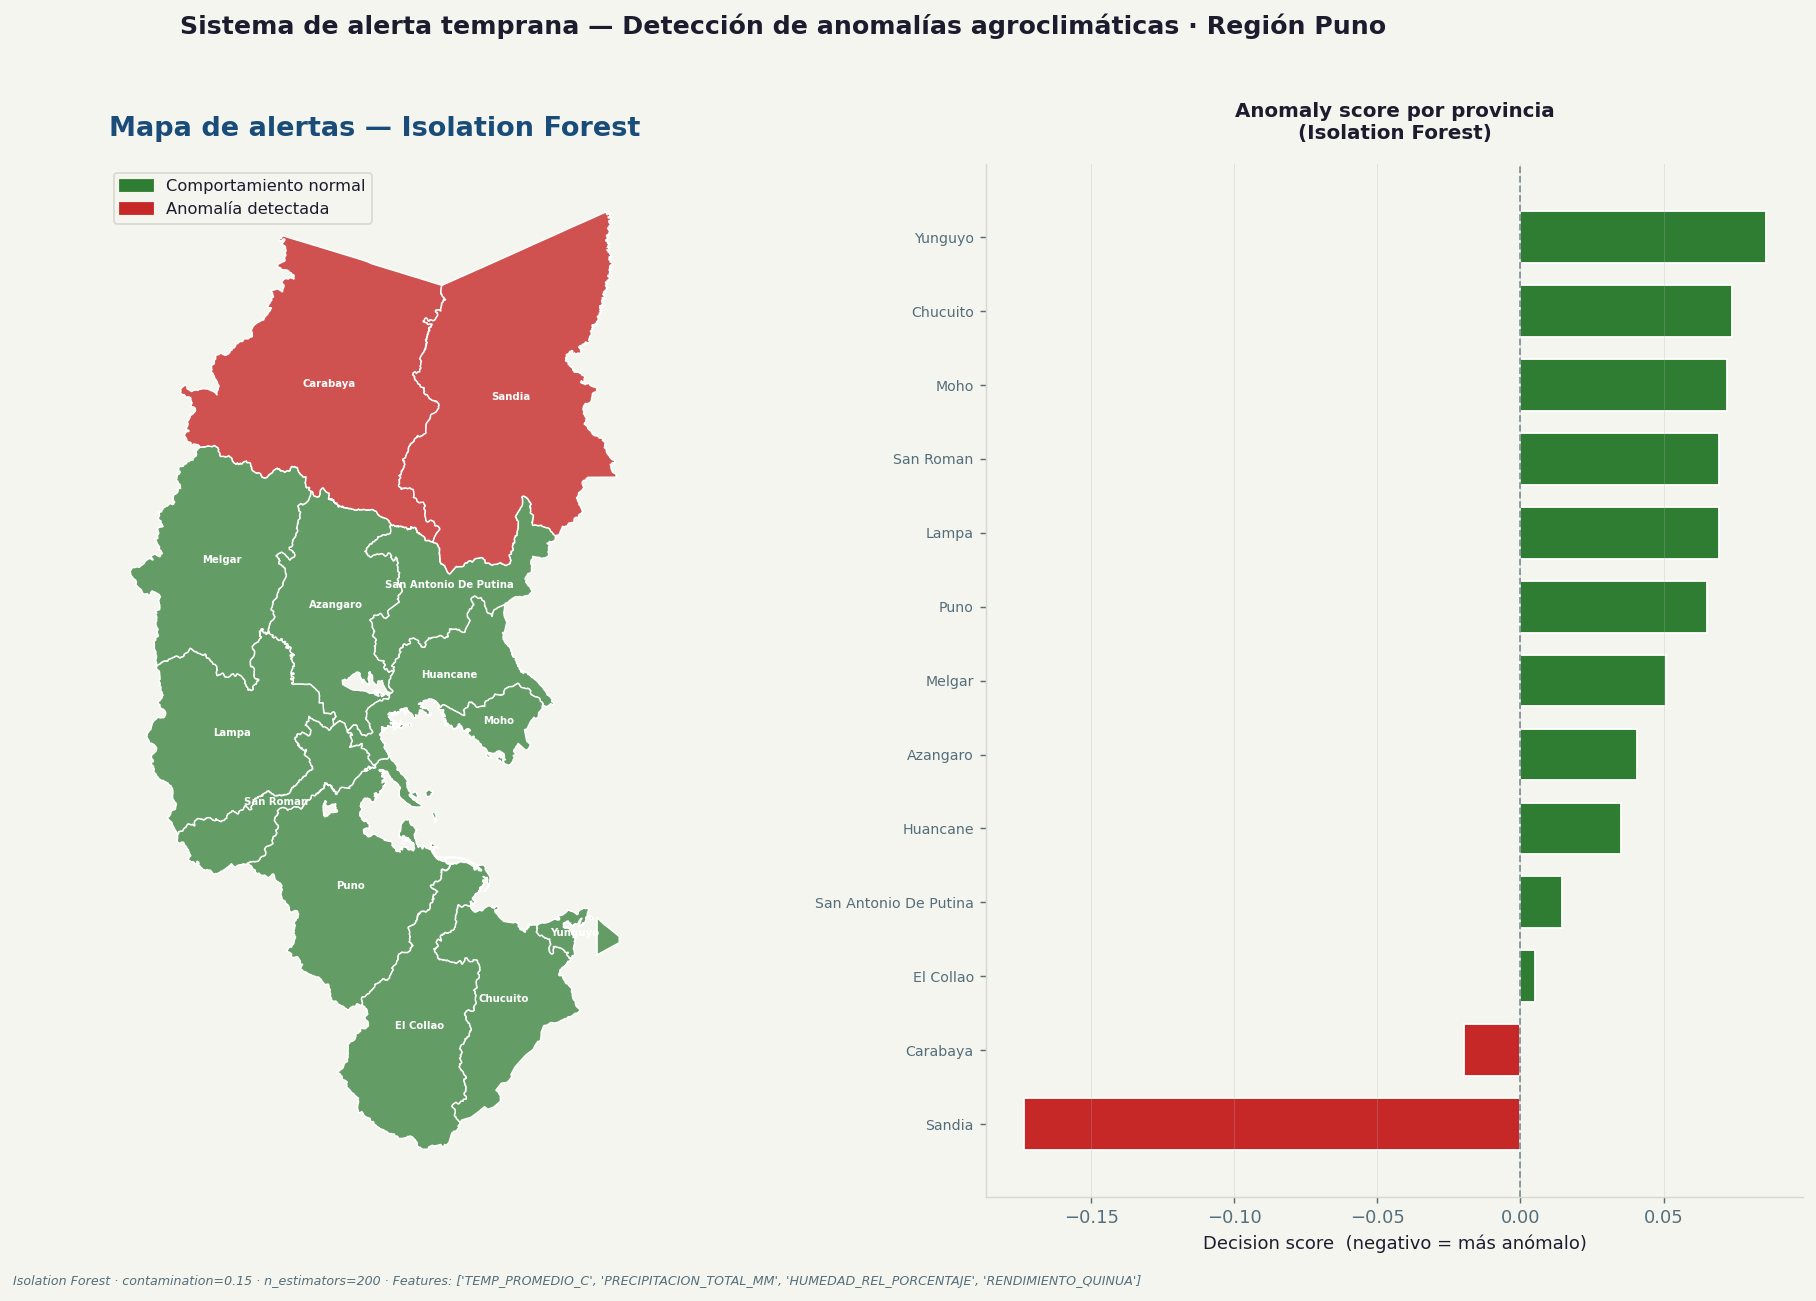


══════════════════════════════════════════════════════════════
   SISTEMA DE ALERTA TEMPRANA — AUDIT RESULT
══════════════════════════════════════════════════════════════
🚨 2 provincia(s) con comportamiento atípico:



,PROVINCIA,TEMP_PROMEDIO_C,PRECIPITACION_TOTAL_MM,HUMEDAD_REL_PORCENTAJE,RENDIMIENTO_QUINUA,IF_SCORE
1,SANDIA,16.41 °C,1845.2 mm,86.1%,0.600 T/Ha,-0.1737
2,CARABAYA,8.21 °C,1346.5 mm,87.1%,0.950 T/Ha,-0.0198



Marco de interpretación:
   Score muy negativo + Rendimiento BAJO  →
      Plaga severa (mildiu, fusarium), sequía ultra-localizada,
      o subregistro de producción (error en datos MINAGRI).
   Score muy negativo + Rendimiento ALTO  →
      Riego tecnificado, variedad mejorada (INIA), o intervención
      agronómica no captada por satélite.

Cell 8 completada.


In [23]:
# CELL 8: Sistema de alerta temprana — Isolation Forest
"""
Detecta provincias con comportamiento agroclimático atípico.
Una provincia es flagged cuando su combinación de clima + rendimiento
resulta estadísticamente improbable dado el manifold de la región.
 
Mejoras:
  · Se expone el decision_function (anomaly score) para ranking continuo.
  · Panel secundario con barras del score por provincia (más informativo que
    solo el mapa binario normal/anómala).
  · Interpretación económica explícita de los distintos tipos de anomalía.
"""
 
from sklearn.ensemble import IsolationForest
 
FEATURES_ANOMALIA = FEATURES_CLIMA + [TARGET]
X_iso = mapa_dataset_final[FEATURES_ANOMALIA].values
 
iso = IsolationForest(
    n_estimators = 200,
    contamination= CONTAMINATION,
    max_samples  = 'auto',
    random_state = RANDOM_STATE,
)
mapa_dataset_final['IF_LABEL'] = iso.fit_predict(X_iso)
mapa_dataset_final['IF_SCORE'] = iso.decision_function(X_iso)
mapa_dataset_final['ES_ANOMALIA'] = mapa_dataset_final['IF_LABEL'] == -1
 
norm_prov = mapa_dataset_final[~mapa_dataset_final['ES_ANOMALIA']]
anom_prov = mapa_dataset_final[mapa_dataset_final['ES_ANOMALIA']]
 
# Figura: mapa + barras de score
fig, (ax_map, ax_bar) = plt.subplots(
    1, 2, figsize=(16, 9.5),
    gridspec_kw={'width_ratios': [1.5, 1]},
)
 
norm_prov.plot(ax=ax_map, color=PALETTE['accent'] + 'BB',
               edgecolor='white', linewidth=0.8, label='Normal')
anom_prov.plot(ax=ax_map, color=PALETTE['danger'] + 'CC',
               edgecolor='white', linewidth=0.8, label='⚠ Anómala')
 
for _, row in mapa_dataset_final.iterrows():
    c = row.geometry.centroid
    ax_map.annotate(row['PROVINCIA'].title(), xy=(c.x, c.y),
                    ha='center', va='center',
                    fontsize=5.6, color='white', fontweight='bold')
 
patches_leg = [
    mpatches.Patch(color=PALETTE['accent'], label='Comportamiento normal'),
    mpatches.Patch(color=PALETTE['danger'], label='Anomalía detectada'),
]
ax_map.legend(handles=patches_leg, loc='upper left', fontsize=9, framealpha=0.92)
ax_map.set_title("Mapa de alertas — Isolation Forest", color=PALETTE['primary'], pad=16)
ax_map.set_axis_off()

_score_df = (
    mapa_dataset_final[['PROVINCIA', 'IF_SCORE', 'ES_ANOMALIA']]
    .sort_values('IF_SCORE')
)
_bar_colors = [PALETTE['danger'] if a else PALETTE['accent']
               for a in _score_df['ES_ANOMALIA']]
 
ax_bar.barh(
    _score_df['PROVINCIA'].str.title(),
    _score_df['IF_SCORE'],
    color=_bar_colors, edgecolor='white', height=0.7,
)
ax_bar.axvline(0, color=PALETTE['neutral'], lw=1.0, ls='--', alpha=0.7)
ax_bar.set_xlabel("Decision score  (negativo = más anómalo)")
ax_bar.set_title("Anomaly score por provincia\n(Isolation Forest)", fontsize=11)
ax_bar.grid(True, alpha=0.3, axis='x', lw=0.5)
ax_bar.tick_params(axis='y', labelsize=7.8)
 
fig.suptitle(
    "Sistema de alerta temprana — Detección de anomalías agroclimáticas · Región Puno",
    fontsize=14, fontweight='bold', y=1.02,
)
fig.text(0.13, -0.01,
         f"Isolation Forest · contamination={CONTAMINATION} · n_estimators=200 · "
         f"Features: {FEATURES_ANOMALIA}",
         fontsize=7, color=PALETTE['neutral'], style='italic')
 
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "08_isolation_forest_alertas.png")
plt.show()
 
# Reporte de anomalías
print(f"\n{'═'*62}")
print("   SISTEMA DE ALERTA TEMPRANA — AUDIT RESULT")
print(f"{'═'*62}")
if anom_prov.empty:
    print("Sin anomalías. Ecosistema agrícola regionalmente consistente.")
else:
    print(f"🚨 {len(anom_prov)} provincia(s) con comportamiento atípico:\n")
    _rpt = (
        anom_prov[['PROVINCIA', 'TEMP_PROMEDIO_C', 'PRECIPITACION_TOTAL_MM',
                   'HUMEDAD_REL_PORCENTAJE', 'RENDIMIENTO_QUINUA', 'IF_SCORE']]
        .sort_values('IF_SCORE')
        .reset_index(drop=True)
    )
    _rpt.index += 1
    display(
        _rpt.style
        .format({
            'TEMP_PROMEDIO_C'        : '{:.2f} °C',
            'PRECIPITACION_TOTAL_MM' : '{:.1f} mm',
            'HUMEDAD_REL_PORCENTAJE' : '{:.1f}%',
            'RENDIMIENTO_QUINUA'     : '{:.3f} T/Ha',
            'IF_SCORE'               : '{:.4f}',
        })
        .background_gradient(subset=['IF_SCORE'], cmap='RdYlGn')
    )
    print("\nMarco de interpretación:")
    print("   Score muy negativo + Rendimiento BAJO  →")
    print("      Plaga severa (mildiu, fusarium), sequía ultra-localizada,")
    print("      o subregistro de producción (error en datos MINAGRI).")
    print("   Score muy negativo + Rendimiento ALTO  →")
    print("      Riego tecnificado, variedad mejorada (INIA), o intervención")
    print("      agronómica no captada por satélite.")
 
print("\nCell 8 completada.")

In [24]:
# CELL 9 │ Visualización 3D — PyDeck ColumnLayer
"""
Renderiza un mapa 3D de columnas (ColumnLayer) con PyDeck.
  · Altura   : proporcional al rendimiento de quinua (Ton/Ha)
  · Color    : semáforo de riesgo según impacto del Fenómeno del Niño
               < −10% → Rojo | < −5% → Naranja | < 0% → Amarillo | ≥ 0% → Verde
  · Tiles    : Carto Dark (sin API key requerida)
  · TextLayer: etiquetas de provincia sobreimpresas
 
FIX respecto al código original:
  · Eliminados parámetros inválidos: iframe_width, iframe_height
    (to_html() solo acepta: filename, open_named_html, notebook_display, css_background_color)
  · Renderización inline en Jupyter usando IPython.display.IFrame
  · Columnas LAT/LON derivadas de mapa_simulacion_geo (correcto) en vez de
    mapa_simulacion que podría no tener CRS=4326
  · Tooltip HTML enriquecido con estilos inline compatibles con pydeck
  · parameters={'depthTest': False} para eliminar artefactos visuales en columnas
    con alturas similares
"""
 
import pydeck as pdk
import pandas as pd
from IPython.display import IFrame, display as ipy_display
import os

# DataFrame plano para PyDeck
if 'LON' not in mapa_simulacion.columns or 'LAT' not in mapa_simulacion.columns:
    _tmp = mapa_simulacion.to_crs(epsg=4326)
    mapa_simulacion = mapa_simulacion.copy()
    mapa_simulacion['LON'] = _tmp.geometry.centroid.x.round(5)
    mapa_simulacion['LAT'] = _tmp.geometry.centroid.y.round(5)
    del _tmp
 
df_3d = pd.DataFrame(mapa_simulacion.drop(columns='geometry'))

for _col in ['TEMP_PROMEDIO_C', 'PRECIPITACION_TOTAL_MM', 'HUMEDAD_REL_PORCENTAJE',
             'RENDIMIENTO_QUINUA', 'IMPACTO_PCT', 'PRED_NORMAL', 'PRED_NINO']:
    if _col in df_3d.columns:
        df_3d[_col] = df_3d[_col].round(3)
 
# Color semáforo de riesgo (RGBA)
def _semaforo(impacto: float) -> list[int]:
    """
    Umbral de riesgo:
      < −10% → Rojo intenso  (crítico)
      < −5%  → Naranja       (alto)
      < 0%   → Amarillo      (moderado)
      ≥  0%  → Verde         (resiliente / neutro)
    """
    if impacto < -10:
        return [198, 40,  40,  225]
    elif impacto < -5:
        return [230, 81,  0,   225]
    elif impacto < 0:
        return [249, 168, 37,  225]
    else:
        return [46,  125, 50,  225]
 
df_3d['COLOR_RGBA'] = df_3d['IMPACTO_PCT'].apply(_semaforo)

ELEV_FACTOR = 15_000
df_3d['ELEV_M'] = (df_3d['RENDIMIENTO_QUINUA'] * ELEV_FACTOR).round(0)
 
# Capas
layer_columnas = pdk.Layer(
    type            = 'ColumnLayer',
    data            = df_3d,
    get_position    = ['LON', 'LAT'],
    get_elevation   = 'ELEV_M',
    elevation_scale = 1,
    radius          = 10_500,
    coverage        = 0.82,
    get_fill_color  = 'COLOR_RGBA',
    pickable        = True,
    auto_highlight  = True,
    extruded        = True,
)
 
layer_texto = pdk.Layer(
    type                  = 'TextLayer',
    data                  = df_3d,
    get_position          = ['LON', 'LAT'],
    get_text              = 'PROVINCIA',
    get_size              = 13,
    get_color             = [255, 255, 255, 210],
    get_angle             = 0,
    get_alignment_baseline= "'bottom'",
    billboard             = True,
    pickable              = False,
)
 
# Cámara
vista = pdk.ViewState(
    longitude= -70.0,
    latitude = -14.5,
    zoom     = 6.5,
    pitch    = 52,
    bearing  = 18,
    min_zoom = 5,
    max_zoom = 12,
)
 
# Tooltip HTML enriquecido
tooltip = {
    "html": (
        "<div style='"
        "font-family:Arial,sans-serif;font-size:12px;"
        "background:rgba(26,76,122,0.96);color:#fff;"
        "padding:10px 14px;border-radius:8px;min-width:210px;"
        "box-shadow:0 2px 12px rgba(0,0,0,0.35);'>"
        "<b style='font-size:14px;'>{PROVINCIA}</b>"
        "<hr style='border-color:rgba(255,255,255,0.25);margin:5px 0'/>"
        "Temperatura media: <b>{TEMP_PROMEDIO_C} °C</b><br/>"
        "Precipitación anual: <b>{PRECIPITACION_TOTAL_MM} mm</b><br/>"
        "Humedad relativa: <b>{HUMEDAD_REL_PORCENTAJE}%</b>"
        "<hr style='border-color:rgba(255,255,255,0.25);margin:5px 0'/>"
        "Rendimiento 2023: <b>{RENDIMIENTO_QUINUA} T/Ha</b><br/>"
        "Pred. normal: <b>{PRED_NORMAL} T/Ha</b><br/>"
        "Pred. del niño: <b>{PRED_NINO} T/Ha</b><br/>"
        "Impacto: <b>{IMPACTO_PCT}%</b>"
        "</div>"
    ),
}
 
# Deck
deck = pdk.Deck(
    layers           = [layer_columnas, layer_texto],
    initial_view_state= vista,
    map_provider     = 'carto',
    map_style        = 'dark',
    tooltip          = tooltip,  # type: ignore  <-- FIX Pylance
    parameters       = {'depthTest': False},
)

# Exportación HTML standalone
_html_3d = OUTPUT_DIR / "09_mapa_3d_riesgo.html"
deck.to_html(
    str(_html_3d),
    open_browser       = False,  # <-- FIX TypeError (era open_named_html)
    notebook_display   = False,
)
print(f"Mapa 3D exportado: {_html_3d}")

# Renderización inline en Jupyter
print("   Renderizando inline...\n")

# Calculamos la ruta relativa para evitar el bloqueo de seguridad de VS Code
ruta_relativa = os.path.relpath(_html_3d).replace('\\', '/')

ipy_display(
    IFrame(src=ruta_relativa, width='100%', height=640)
)

print("Cell 9 completada.")


Mapa 3D exportado: G:\2026\Trabajos\Agriapatial-ML descubrimiento de microclimas y predicción de rendimientos mediante inteligencia artificial\spatial-agri-production\outputs\09_mapa_3d_riesgo.html
   Renderizando inline...



Cell 9 completada.


In [25]:
# CELL 10: Resumen
"""
Consolida los principales hallazgos del pipeline en un único reporte impreso.
"""

print("RESUMEN EJECUTIVO — AgroSpatial-ML · Región Puno")
print(f"Año de análisis: {AÑO_ANALISIS}")
print(f"Provincias analizadas: {len(mapa_dataset_final):<3}")
print(f"Rendimiento medio: {mapa_dataset_final[TARGET].mean():.3f} Ton/Ha")
print("MICROCLIMAS DESCUBIERTOS")
for _n in mapa_dataset_final['MICROCLIMA'].unique():
    _sub = mapa_dataset_final[mapa_dataset_final['MICROCLIMA'] == _n]
    print(f"· {_n:<40} ({len(_sub)} prov.)")
print(f"RANDOM FOREST — Evaluación LOO")
print(f"RMSE_LOO = {rmse_loo:.4f} T/Ha  │  R²_LOO = {r2_loo:.4f}")
print(f"SIMULACIÓN DEL NIÑO (+2 °C · −30% lluvia)")
_imp_mean = mapa_simulacion['IMPACTO_PCT'].mean()
_imp_min  = mapa_simulacion['IMPACTO_PCT'].min()
_prov_max_riesgo = mapa_simulacion.loc[mapa_simulacion['IMPACTO_PCT'].idxmin(), 'PROVINCIA']
print(f"Impacto medio regional: {_imp_mean:.1f}%")
print(f"Provincia más vulnerable: {str(_prov_max_riesgo).title():<20} ({_imp_min:.1f}%)")
print(f"ANOMALÍAS DETECTADAS: {len(anom_prov)} provincia(s) (IF contamination={CONTAMINATION})")
print("OUTPUTS GENERADOS")
for _f in sorted(OUTPUT_DIR.glob("*.png")) + sorted(OUTPUT_DIR.glob("*.html")):
    print(f"· {_f.name:<60}")
 

RESUMEN EJECUTIVO — AgroSpatial-ML · Región Puno
Año de análisis: 2023
Provincias analizadas: 13 
Rendimiento medio: 1.305 Ton/Ha
MICROCLIMAS DESCUBIERTOS
· Microclima B                             (8 prov.)
· Microclima C                             (4 prov.)
· Microclima A                             (1 prov.)
RANDOM FOREST — Evaluación LOO
RMSE_LOO = 0.2328 T/Ha  │  R²_LOO = 0.2441
SIMULACIÓN DEL NIÑO (+2 °C · −30% lluvia)
Impacto medio regional: 2.0%
Provincia más vulnerable: Azangaro             (-9.2%)
ANOMALÍAS DETECTADAS: 2 provincia(s) (IF contamination=0.15)
OUTPUTS GENERADOS
· 01_mapa_provincial_puno.png                                 
· 02_mapa_rendimiento_quinua.png                              
· 04a_elbow_silhouette.png                                    
· 04b_mapa_microclimas.png                                    
· 05_random_forest_evaluacion.png                             
· 06_mapa_riesgo_nino.png                                     
· 08_isolation_forest_alertas